### This demo runs much faster on a GPU runtime (e.g., Colab: Runtime → Change runtime type → GPU).


In [1]:
from pathlib import Path
import sys
import subprocess
import json
import random
import importlib.util
import os
import shlex

# --- Colab-friendly helpers ---
try:
    from IPython import get_ipython
except Exception:  # pragma: no cover - best effort
    get_ipython = lambda: None


def is_colab():
    return (
        "google.colab" in sys.modules
        or "COLAB_RELEASE_TAG" in os.environ
        or "COLAB_GPU" in os.environ
    )


def run_cmd(cmd, *, cwd=None, check=True):
    if isinstance(cmd, (list, tuple)):
        cmd_list = [str(c) for c in cmd]
        cmd_str = " ".join(shlex.quote(c) for c in cmd_list)
    else:
        cmd_list = None
        cmd_str = str(cmd)

    if is_colab():
        ip = get_ipython()
        if ip is not None:
            status = ip.system(cmd_str)
            if check and status not in (0, None):
                raise RuntimeError(f"Command failed with status {status}: {cmd_str}")
            return status

    if cmd_list is None:
        return subprocess.run(cmd_str, shell=True, check=check, cwd=cwd)
    return subprocess.run(cmd_list, check=check, cwd=cwd)


# --- clone repo if needed ---
REPO_URL = "https://github.com/AhmedTarek62/wavesfm"
if (Path.cwd() / "main_finetune.py").exists():
    REPO_DIR = Path.cwd()
else:
    REPO_DIR = Path("/content/wavesfm")
    if not REPO_DIR.exists():
        run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)])
    os.chdir(REPO_DIR)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

# --- install missing deps (Colab) ---
def _ensure_pkg(module, pip_name=None):
    if importlib.util.find_spec(module) is None:
        pkg = pip_name or module
        run_cmd([sys.executable, "-m", "pip", "install", "-q", pkg])

if importlib.util.find_spec("torch") is None:
    run_cmd([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision", "torchaudio"
    ])

for mod, pip_name in [
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("h5py", "h5py"),
    ("scipy", "scipy"),
    ("tqdm", "tqdm"),
    ("timm", "timm"),
    ("pandas", "pandas"),
    ("PIL", "pillow"),
    ("huggingface_hub", "huggingface_hub"),
    ("DeepMIMOV3", "DeepMIMOV3"),
]:
    _ensure_pkg(mod, pip_name)

import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


Cloning into '/content/wavesfm'...
remote: Enumerating objects: 416, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 416 (delta 76), reused 92 (delta 40), pack-reused 281 (from 1)
Receiving objects: 100% (416/416), 509.61 KiB | 8.35 MiB/s, done.
Resolving deltas: 100% (252/252), done.


## Configuration


In [16]:
# Configuration
TASK = "uwb-industrial"   # {"sensing", "deepmimo-los", "rml", "uwb-industrial"}
DOWNLOAD_DATA = True      # set False if you already downloaded the raw files
SEED = 1
VAL_SPLIT = 0.2
NUM_WORKERS = 4

# Demo epochs (small by default; increase for better metrics)
EPOCHS_BY_TASK = {"rml": 10, "deepmimo-los": 10, "uwb-industrial": 20,}
DEFAULT_EPOCHS = 50
BATCH_SIZE_BY_TASK = {"rml": 2048, "uwb-industrial": 1024}
DEFAULT_BATCH = 256

epochs = EPOCHS_BY_TASK.get(TASK, DEFAULT_EPOCHS)
batch_size = BATCH_SIZE_BY_TASK.get(TASK, DEFAULT_BATCH)

# Finetuning regime
FINETUNE_MODE = "ft2"  # {"lp", "ft2", "lora"}
FT2_FROZEN_BLOCKS = 6
LORA_RANK = 32
LORA_ALPHA = 64

STRATIFIED_TASKS = {"deepmimo-los"}
SMOOTH_TASKS = {"sensing": 0.1}

# Paths
DATA_ROOT = Path("data")
RAW_ROOT = DATA_ROOT / "raw"
CACHE_ROOT = DATA_ROOT / "cache"
OUTPUT_DIR = Path("runs/demo") / TASK
CHECKPOINT_DIR = Path("checkpoints")

for p in (RAW_ROOT, CACHE_ROOT, CHECKPOINT_DIR, OUTPUT_DIR):
    p.mkdir(parents=True, exist_ok=True)

# Raw dataset locations (after download/extraction)
HAS_DIR = RAW_ROOT / "NTU-Fi_HAR"              # EfficientFi HAS (sensing)
RML_DATA_FILE = RAW_ROOT / "RML22.01A"            # RML 2022 (rml)
UWB_INDUSTRIAL_DATA_FILE = RAW_ROOT / "industrial_training.pkl"  # UWB Industrial (uwb-industrial)
DEEPMIMO_SCENARIOS_DIR = RAW_ROOT / "deepmimo_scenarios"          # DeepMIMO scenarios clone target
DEEPMIMO_IMG_SIZE = 32
DEEPMIMO_CLONE = True


**Demo note:** this notebook uses a *small* number of epochs by default for quick runs. Increase `DEFAULT_EPOCHS` / `EPOCHS_BY_TASK` for better metrics.


## Helpers


In [14]:
import re
from types import SimpleNamespace
from torch.utils.data import DataLoader, Subset

from data import build_datasets
from main_finetune import build_model


def _unwrap_subset_with_indices(ds):
    if not isinstance(ds, Subset):
        return ds, None
    indices = list(ds.indices)
    base = ds.dataset
    while isinstance(base, Subset):
        indices = [base.indices[i] for i in indices]
        base = base.dataset
    return base, np.asarray(indices, dtype=np.int64)


def _load_label_names(ds, task_info):
    base, _ = _unwrap_subset_with_indices(ds)
    labels = getattr(base, "labels", None)
    if labels:
        return list(labels)
    h5_path = getattr(base, "h5_path", None)
    if h5_path:
        with h5py.File(h5_path, "r") as h5:
            raw = h5.attrs.get("labels", None)
            if raw:
                return list(json.loads(raw))
            raw = h5.attrs.get("labels_los", None)
            if raw:
                return list(json.loads(raw))
    return [str(i) for i in range(task_info.num_outputs)]


def plot_samples(ds, task_info, *, seed=0, num_show=6, anchor_idx=0):
    rng = random.Random(seed)
    num_show = min(num_show, len(ds))
    indices = rng.sample(range(len(ds)), num_show)

    def _to_numpy(x):
        if torch.is_tensor(x):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    def _label_text(label):
        if torch.is_tensor(label):
            label = label.detach().cpu().numpy()
        label = np.asarray(label)
        if label.shape == ():
            return f"label={int(label)}"
        return f"label={np.array2string(label, precision=2, separator=',')}"

    def _plot_rml(ax, sample):
        x = _to_numpy(sample)
        if x.ndim == 3 and x.shape[1] == 1:
            x = x[:, 0, :]
        i = x[0]
        q = x[1]
        ax.plot(i, label="I")
        ax.plot(q, label="Q")
        ax.legend(fontsize=6)
        ax.axis("off")

    def _plot_uwb(ax, sample):
        x = _to_numpy(sample)
        if x.ndim != 3 or x.shape[0] < 2:
            ax.plot(x.flatten())
            ax.axis("off")
            return
        a = min(anchor_idx, x.shape[1] - 1)
        i = x[0, a]
        q = x[1, a]
        ax.plot(i, label="I")
        ax.plot(q, label="Q")
        ax.legend(fontsize=6)
        ax.axis("off")

    def _plot_deepmimo(ax, sample):
        x = _to_numpy(sample)
        real = x[0]
        imag = x[1]
        mag = np.abs(real + 1j * imag)
        ax.imshow(mag, cmap="viridis")
        ax.axis("off")

    def _plot_sensing(ax, sample):
        x = _to_numpy(sample)
        if x.ndim == 3:
            x = (x - x.min()) / (x.max() - x.min() + 1e-8)
            img = np.moveaxis(x, 0, -1)
            ax.imshow(img)
            ax.axis("off")
        else:
            ax.plot(x.flatten())
            ax.axis("off")

    fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
    if num_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        batch = ds[idx]
        if len(batch) == 2:
            sample, label = batch
        elif len(batch) == 3:
            sample, label = batch[0:2]
        else:
            raise ValueError("Unexpected sample format from dataset")
        if TASK == "rml":
            _plot_rml(ax, sample)
        elif TASK == "uwb-industrial":
            _plot_uwb(ax, sample)
        elif TASK == "deepmimo-los":
            _plot_deepmimo(ax, sample)
        elif TASK == "sensing":
            _plot_sensing(ax, sample)
        else:
            ax.plot(_to_numpy(sample).flatten())
            ax.axis("off")
        ax.set_title(_label_text(label))
    plt.show()


def pick_eval_ckpt(output_dir: Path) -> Path:
    best = output_dir / "best.pth"
    if best.exists():
        return best
    candidates = list(output_dir.glob("checkpoint_*.pth"))
    if candidates:
        def _ckpt_epoch(path: Path) -> int:
            match = re.search(r"checkpoint_(\d+)\.pth", path.name)
            return int(match.group(1)) if match else -1
        return max(candidates, key=_ckpt_epoch)
    raise FileNotFoundError(f"No checkpoints found in {output_dir}")


def load_eval_model(ckpt_path: Path, task_info, *, device: str = "cpu"):
    model_args = SimpleNamespace(
        model="vit_multi_small",
        global_pool="token",
        vis_patch=16,
        vis_img_size=DEEPMIMO_IMG_SIZE if TASK.startswith("deepmimo") else 224,
        iq_segment_len=16,
        iq_downsample=None,
        iq_target_len=256,
        use_conditional_ln=True,
    )
    model = build_model(model_args, task_info)
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    state = ckpt.get("model", ckpt) if isinstance(ckpt, dict) else ckpt
    model.load_state_dict(state, strict=False)
    model.to(device)
    model.eval()
    return model


def plot_confusion_matrix(model, val_ds, task_info, *, batch_size=256, device="cpu", annotate=True):
    loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    num_classes = task_info.num_outputs
    conf = np.zeros((num_classes, num_classes), dtype=int)

    with torch.no_grad():
        for batch in loader:
            samples, targets = batch[0].to(device), batch[1].to(device).long()
            outputs = model(samples)
            preds = outputs.argmax(dim=1)
            for t, p in zip(targets.cpu().numpy(), preds.cpu().numpy()):
                conf[int(t), int(p)] += 1

    with np.errstate(divide="ignore", invalid="ignore"):
        row_sums = conf.sum(axis=1, keepdims=True)
        conf_norm = np.divide(conf, row_sums, out=np.zeros_like(conf, dtype=float), where=row_sums != 0)

    label_names = _load_label_names(val_ds, task_info)
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(conf_norm, cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(f"Confusion Matrix ({TASK})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)

    if annotate:
        for i in range(num_classes):
            for j in range(num_classes):
                val = conf_norm[i, j]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_position_error_pdf(model, val_ds, *, batch_size=256, device="cpu", bins=60):
    base, _ = _unwrap_subset_with_indices(val_ds)
    if not hasattr(base, "loc_min") or not hasattr(base, "loc_max"):
        print("UWB location metadata missing; skipping error PDF plot.")
        return

    coord_min = base.loc_min.to(device)
    coord_max = base.loc_max.to(device)

    def _denorm(x):
        return (x + 1) * 0.5 * (coord_max - coord_min) + coord_min

    loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    errors = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            samples, targets = batch[0].to(device), batch[1].to(device)
            outputs = model(samples)
            pred = _denorm(outputs)
            true = _denorm(targets)
            dist = torch.linalg.norm(pred - true, dim=-1)
            errors.append(dist.detach().cpu().numpy())

    if not errors:
        print("No samples available for error PDF plot.")
        return

    errors = np.concatenate(errors, axis=0).astype(np.float64)
    n = int(errors.size)
    max_bins = max(20, int(np.sqrt(n)))
    effective_bins = min(bins, max_bins)
    hist, edges = np.histogram(errors, bins=effective_bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    mean = float(errors.mean())

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(centers, hist, color="#1f77b4", linewidth=2)
    ax.fill_between(centers, hist, color="#1f77b4", alpha=0.25)
    ax.axvline(mean, color="#d62728", linestyle="--", linewidth=1.5)
    ax.text(
        0.98,
        0.95,
        f"mean={mean:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="#d62728",
    )
    ax.set_xlabel("Position error distance")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_rml_accuracy_vs_snr(model, val_ds, *, batch_size=256, device="cpu"):
    base, idxs = _unwrap_subset_with_indices(val_ds)
    snr_by_index = getattr(base, "snr_by_index", None)
    if snr_by_index is None:
        print("SNR metadata not found; skipping accuracy vs SNR plot.")
        return

    snrs = np.asarray(snr_by_index, dtype=np.int16)
    if idxs is not None:
        snrs = snrs[idxs]

    loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    offset = 0
    correct = {}
    total = {}

    with torch.no_grad():
        for batch in loader:
            samples, targets = batch[0].to(device), batch[1].to(device).long()
            outputs = model(samples)
            preds = outputs.argmax(dim=1)
            batch_snrs = snrs[offset: offset + len(targets)]
            offset += len(targets)

            for snr_val, p, t in zip(batch_snrs, preds.cpu().numpy(), targets.cpu().numpy()):
                snr_val = int(snr_val)
                total[snr_val] = total.get(snr_val, 0) + 1
                correct[snr_val] = correct.get(snr_val, 0) + int(p == t)

    snr_levels = sorted(total.keys())
    acc = [correct[s] / total[s] for s in snr_levels]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(snr_levels, acc, marker="o")
    ax.set_title("RML Accuracy vs SNR")
    ax.set_xlabel("SNR")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Download raw datasets

This notebook supports a **subset of tasks** only. For deeper experiments (more tasks, configs, and training options), refer to the full repository: https://github.com/AhmedTarek62/wavesfm

### Vision tasks
- `sensing` — EfficientFi (Human Activity Sensing): https://github.com/xyanchen/WiFi-CSI-Sensing-Benchmark  
- `deepmimo-los` — DeepMIMO LoS/NLoS classification (generated locally via `preprocess_deepmimo.py`; no manual downloads)

### IQ tasks
- `rml` — RML 2022 (Modulation Classification): https://github.com/venkateshsathya/RML22  
- `uwb-industrial` — UWB Industrial Positioning: https://owncloud.fraunhofer.de/index.php/s/AXFjGY9IhswfBSa/download

#
> **Note:** Links were valid at the time this notebook was published. If a link breaks, please use the corresponding project page above to locate the latest download instructions.


In [17]:
# Optional dataset download
from huggingface_hub import hf_hub_download

HF_DATA_REPO = "ahmedaboulfo/icc-demo"

if not DOWNLOAD_DATA:
    print("DOWNLOAD_DATA=False → assuming raw files already exist under:", RAW_ROOT)

elif TASK == "sensing":
    # EfficientFi HAS from Hugging Face
    zip_path = Path(hf_hub_download(
        repo_id=HF_DATA_REPO,
        repo_type="dataset",
        filename="NTU-Fi_HAR.zip",
        local_dir=str(RAW_ROOT),
    ))
    run_cmd(["unzip", "-o", str(zip_path), "-d", str(RAW_ROOT)])
    zip_path.unlink(missing_ok=True)

elif TASK == "deepmimo-los":
    print("DeepMIMO is generated during preprocessing; no download step needed.")

elif TASK == "rml":
    # RML 2022 from Hugging Face
    hf_hub_download(
        repo_id=HF_DATA_REPO,
        repo_type="dataset",
        filename="RML22.01A",
        local_dir=str(RAW_ROOT),
    )

elif TASK == "uwb-industrial":
    # UWB Industrial Positioning (Fraunhofer ownCloud)
    UWB_URL = "https://owncloud.fraunhofer.de/index.php/s/AXFjGY9IhswfBSa/download"
    pkl_path = UWB_INDUSTRIAL_DATA_FILE
    run_cmd(["wget", "-O", str(pkl_path), UWB_URL])

else:
    raise ValueError(f"Unknown TASK={TASK!r}. Expected one of: sensing, deepmimo-los, rml, uwb-industrial.")


--2026-10-01 05:52:10--  https://owncloud.fraunhofer.de/index.php/s/AXFjGY9IhswfBSa/download
Resolving owncloud.fraunhofer.de (owncloud.fraunhofer.de)... 153.97.181.54
Connecting to owncloud.fraunhofer.de (owncloud.fraunhofer.de)|153.97.181.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 575810460 (549M) [application/octet-stream]
Saving to: ‘data/raw/industrial_training.pkl’

data/raw/industrial 100%[===================>] 549.13M  12.9MB/s    in 45s     

2026-10-01 05:52:56 (12.2 MB/s) - ‘data/raw/industrial_training.pkl’ saved [575810460/575810460]



## Create preprocessed .h5 cache from raw data


In [18]:
# --- cache path ---
if TASK == "sensing":
    CACHE_PATH = CACHE_ROOT / "has.h5"
elif TASK == "deepmimo-los":
    CACHE_PATH = CACHE_ROOT / "deepmimo.h5"
elif TASK == "rml":
    CACHE_PATH = CACHE_ROOT / "rml2022.h5"
elif TASK == "uwb-industrial":
    CACHE_PATH = CACHE_ROOT / "uwb-industrial.h5"
else:
    raise ValueError(f"Unsupported TASK: {TASK}")

print("Task:", TASK)
print("Cache path:", CACHE_PATH)

# --- preprocess (skip this cell if you already have CACHE_PATH) ---
if TASK == "sensing":
    run_cmd([
        sys.executable, "preprocessing/preprocess_csi_sensing.py",
        "--data-path", str(HAS_DIR),
        "--output", str(CACHE_PATH),
        "--overwrite"], check=True)

elif TASK == "deepmimo-los":
    deepmimo_cmd = [
        sys.executable, "preprocessing/preprocess_deepmimo.py",
        "--output", str(CACHE_PATH),
        "--dataset-folder", str(DEEPMIMO_SCENARIOS_DIR),
        "--resize-size", str(DEEPMIMO_IMG_SIZE),
        "--overwrite",
    ]
    if DEEPMIMO_CLONE:
        deepmimo_cmd.append("--clone-scenarios")
    run_cmd(deepmimo_cmd, check=True)

elif TASK == "rml":
    if not RML_DATA_FILE.exists():
        raise FileNotFoundError(f"Missing RML file at {RML_DATA_FILE}")
    run_cmd([
        sys.executable, "preprocessing/preprocess_rml.py",
        "--data-file", str(RML_DATA_FILE),
        "--version", "2022",
        "--output", str(CACHE_PATH),
        "--overwrite",
    ], check=True)

elif TASK == "uwb-industrial":
    if not UWB_INDUSTRIAL_DATA_FILE.exists():
        raise FileNotFoundError(f"Missing UWB-Industrial file at {UWB_INDUSTRIAL_DATA_FILE}")
    run_cmd([
        sys.executable, "preprocessing/preprocess_ipin_loc.py",
        "--data-path", str(UWB_INDUSTRIAL_DATA_FILE),
        "--output", str(CACHE_PATH),
        "--overwrite",
    ], check=True)

TRAIN_CACHE_PATH = CACHE_PATH
print("Train cache path:", TRAIN_CACHE_PATH)


Task: uwb-industrial
Cache path: data/cache/uwb-industrial.h5
Indexing IPIN groups: 100% 44801/44801 [00:27<00:00, 1632.72it/s]
Total groups: 44801 | kept: 40264 | dropped: 4537
Groups with position mismatch > 0.001: 26200
Writing IPIN samples: 100% 44801/44801 [01:30<00:00, 492.68it/s]
Wrote IPIN cache to data/cache/uwb-industrial.h5
Train cache path: data/cache/uwb-industrial.h5


## Visualize cached samples


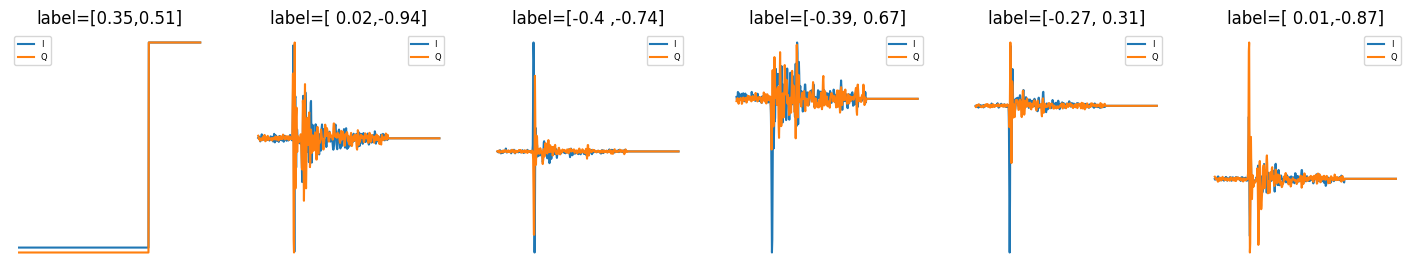

Task info: iq


In [19]:
train_ds, val_ds, task_info = build_datasets(
    TASK,
    str(TRAIN_CACHE_PATH),
    val_path=None,
    val_split=VAL_SPLIT,
    stratified_split=TASK in STRATIFIED_TASKS,
    seed=SEED,
)

plot_samples(train_ds, task_info, seed=SEED)
print("Task info:", task_info.modality)


## Download pretrained checkpoint


In [20]:
from hub import download_pretrained

HF_REPO = "ahmedaboulfo/wavesfm"
HF_FILE = "wavesfm-v1p0.pth"

PRETRAINED_PATH = Path(
    download_pretrained(repo_id=HF_REPO, filename=HF_FILE, cache_dir=str(CHECKPOINT_DIR))
)
print("Downloaded to:", PRETRAINED_PATH)


Downloaded to: /content/wavesfm/checkpoints/models--ahmedaboulfo--wavesfm/snapshots/6a63011e7cbc4ea05ec664d02643e7330c9cc503/wavesfm-v1p0.pth


## Finetune


In [21]:
# --- finetune (match run_finetune_all.py defaults, seed 0) ---
train_cmd = [
    sys.executable, "main_finetune.py",
    "--task", TASK,
    "--train-data", str(TRAIN_CACHE_PATH),
    "--output-dir", str(OUTPUT_DIR),
    "--batch-size", str(batch_size),
    "--num-workers", str(NUM_WORKERS),
    "--epochs", str(epochs),
    "--seed", str(SEED),
    "--val-split", str(VAL_SPLIT),
    "--model", "vit_multi_small",
    "--warmup-epochs", "5",
    "--use-conditional-ln",
    "--finetune", str(PRETRAINED_PATH),
]

if FINETUNE_MODE == "lora":
    train_cmd += ["--lora", "--lora-rank", str(LORA_RANK), "--lora-alpha", str(LORA_ALPHA)]
elif FINETUNE_MODE == "ft2":
    train_cmd += ["--frozen-blocks", str(FT2_FROZEN_BLOCKS)]
elif FINETUNE_MODE != "lp":
    raise ValueError(f"Unknown FINETUNE_MODE={FINETUNE_MODE!r}. Expected lp/ft2/lora.")

if TASK in STRATIFIED_TASKS:
    train_cmd += ["--stratified-split", "--class-weights"]
if TASK in SMOOTH_TASKS:
    train_cmd += ["--smoothing", str(SMOOTH_TASKS[TASK])]
if TASK.startswith("deepmimo"):
    train_cmd += ["--vis-img-size", str(DEEPMIMO_IMG_SIZE)]

run_cmd(train_cmd, check=True)


[data] task=uwb-industrial train=32212 val=8052
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
[init] loaded finetune checkpoint /content/wavesfm/checkpoints/models--ahmedaboulfo--wavesfm/snapshots/6a63011e7cbc4ea05ec664d02643e7330c9cc503/wavesfm-v1p0.pth
_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=['mask_token', 'vis_pos_embed', 'vis_dec_pos_embed', 'iq_time_pos_embed', 'iq_dec_time_pos_embed', 'decoder_embed.weight', 'decoder_embed.bias', 'decoder_blocks.0.norm1.weight', 'decoder_blocks.0.norm1.bias', 'decoder_blocks.0.attn.qkv

## Load evaluation checkpoint


In [22]:
best_ckpt = pick_eval_ckpt(OUTPUT_DIR)
print(f"Eval checkpoint: {best_ckpt}")

device = "cuda" if torch.cuda.is_available() else "cpu"
train_ds, val_ds, task_info = build_datasets(
    TASK,
    str(TRAIN_CACHE_PATH),
    val_path=None,
    val_split=VAL_SPLIT,
    stratified_split=TASK in STRATIFIED_TASKS,
    seed=SEED,
)

eval_model = load_eval_model(best_ckpt, task_info, device=device)


Eval checkpoint: runs/demo/uwb-industrial/best.pth


## Evaluation & plots


Demo run: 20 epochs (mode: ft2). Metrics are indicative.
[data] task=uwb-industrial train=32212 val=8052
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
[init] loaded finetune checkpoint runs/demo/uwb-industrial/best.pth
<All keys matched successfully>
[model] vit_multi_small total=6.33M trainable=0.01M
[params] total=6.33M trainable=14.85K frozen=6.32M
[params] trainable groups:
  - tokenizer: 12.54K
  - conditional_ln: 1.02K
  - head: 514
  - norm: 512
  - cls_token: 256
[params] frozen groups:
  - blocks: 6.32M
/usr/local/lib/python3.13/dist-packages/torch/uti

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


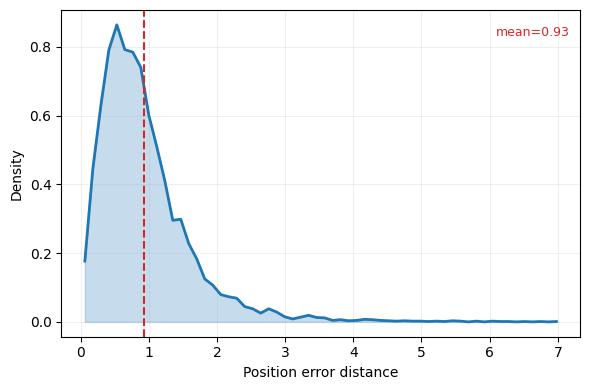

In [23]:
# --- eval-only metrics ---
print(f"Demo run: {epochs} epochs (mode: {FINETUNE_MODE}). Metrics are indicative.")

eval_cmd = [
    sys.executable, "main_finetune.py",
    "--task", TASK,
    "--train-data", str(TRAIN_CACHE_PATH),
    "--batch-size", str(batch_size),
    "--num-workers", str(NUM_WORKERS),
    "--seed", str(SEED),
    "--val-split", str(VAL_SPLIT),
    "--model", "vit_multi_small",
    "--warmup-epochs", "5",
    "--use-conditional-ln",
    "--eval-only",
    "--finetune", str(best_ckpt),
]

if TASK in STRATIFIED_TASKS:
    eval_cmd += ["--stratified-split", "--class-weights"]
if TASK in SMOOTH_TASKS:
    eval_cmd += ["--smoothing", str(SMOOTH_TASKS[TASK])]
if TASK.startswith("deepmimo"):
    eval_cmd += ["--vis-img-size", str(DEEPMIMO_IMG_SIZE)]

run_cmd(eval_cmd, check=True)

# --- plots ---
if task_info.target_type == "classification":
    plot_confusion_matrix(eval_model, val_ds, task_info, batch_size=batch_size, device=device, annotate=(TASK != "rml"))

if TASK == "uwb-industrial":
    plot_position_error_pdf(eval_model, val_ds, batch_size=batch_size, device=device)

if TASK == "rml":
    plot_rml_accuracy_vs_snr(eval_model, val_ds, batch_size=batch_size, device=device)
